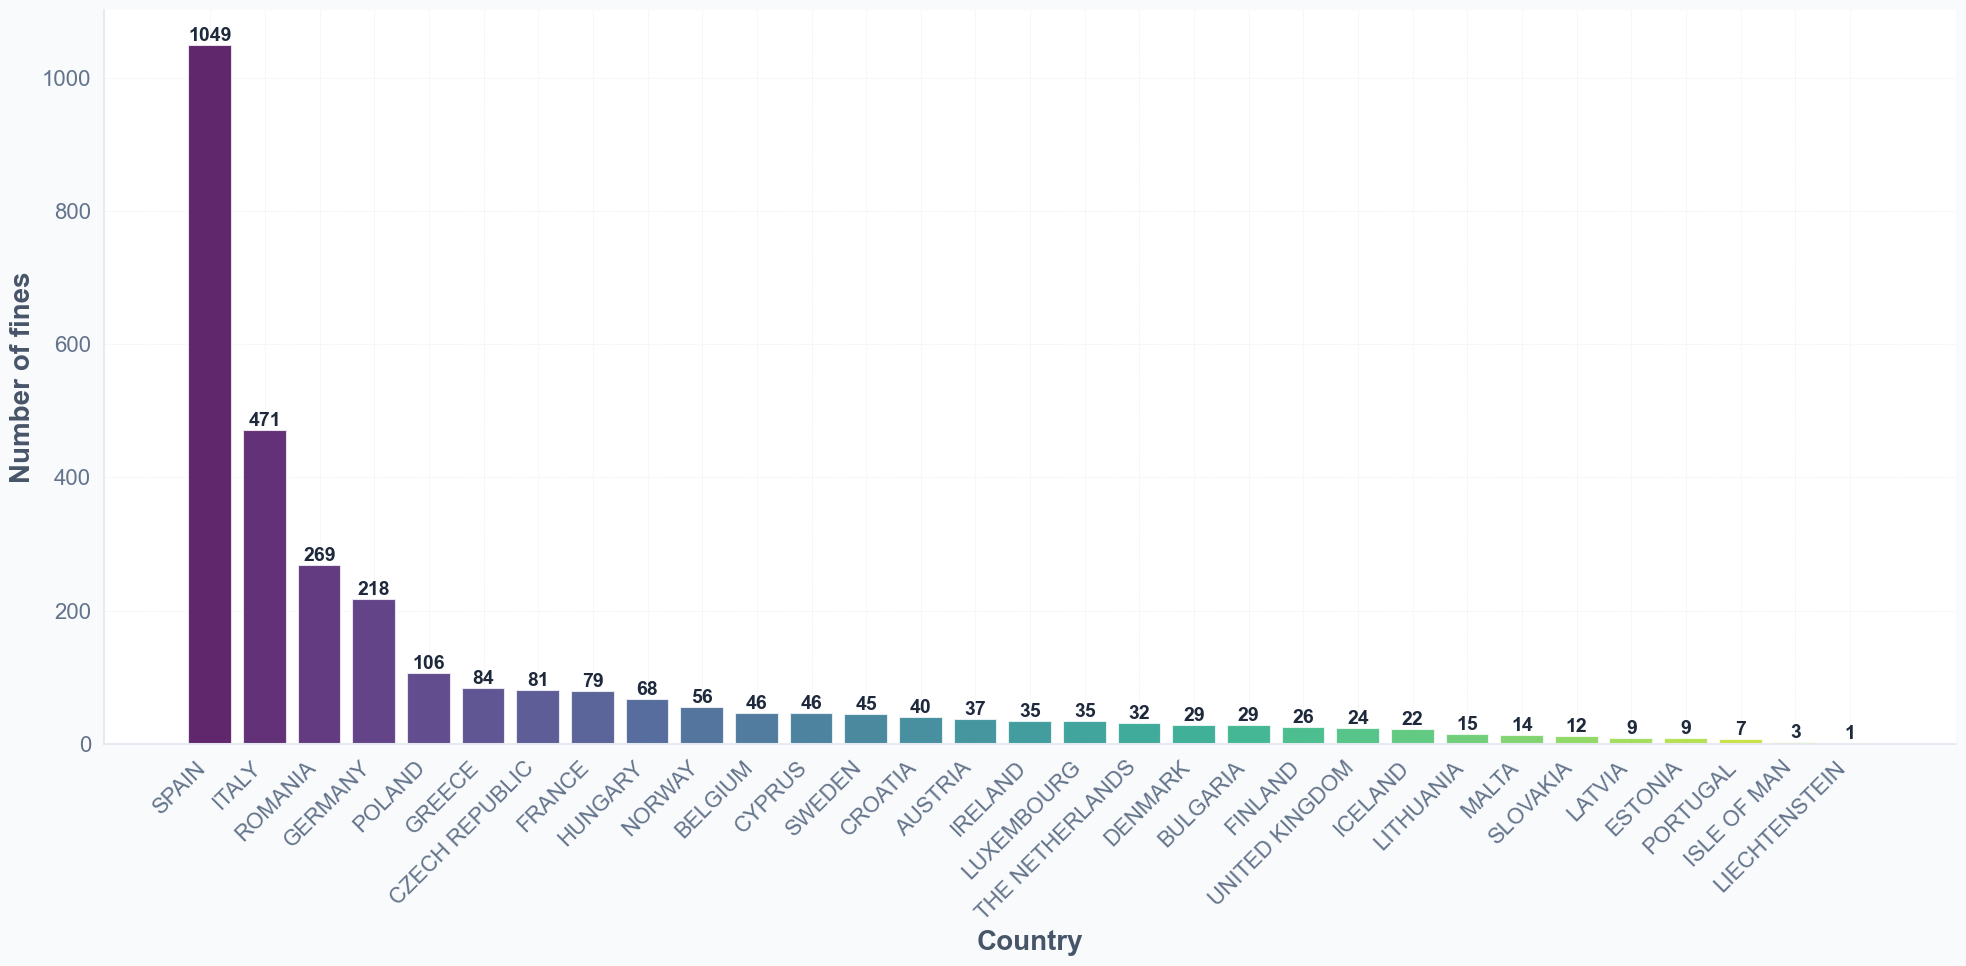

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Set theme with larger font sizes ---
sns.set_theme(style="whitegrid", font_scale=1.5)

# --- 1. Read CSV ---
df = pd.read_csv("gdpr_fines_summary_21_Jan_2026_v2.xlsx - figure.csv")

# --- 2. Group by Country only ---
summary = (
    df.groupby("Country")
      .size()
      .reset_index(name="Count")
      .sort_values("Count", ascending=False)
)

# --- 3. Create color palette ---
n_countries = len(summary)
colors = [plt.cm.viridis(i / n_countries) for i in range(n_countries)]

# --- 4. Plot ---
fig, ax = plt.subplots(figsize=(20, 10))
fig.patch.set_facecolor('#f8fafc')  # Light gray background
ax.set_facecolor('#ffffff')  # White plot background

bars = ax.bar(
    summary["Country"],
    summary["Count"],
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

# Add gradient effect to bars
for i, bar in enumerate(bars):
    bar.set_alpha(0.85)

# --- Add numbers on top of bars ---
for i, (bar, count) in enumerate(zip(bars, summary["Count"])):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x position (center of bar)
        height,  # y position (top of bar)
        f'{int(count)}',  # text to display
        ha='center',  # horizontal alignment
        va='bottom',  # vertical alignment
        fontsize=14,
        fontweight='bold',
        color='#1e293b'
    )

# plt.title("GDPR Fines by Country", fontsize=28, fontweight='bold', color='#1e293b', pad=20)
plt.xlabel("Country", fontsize=20, fontweight='bold', color='#475569')
plt.ylabel("Number of fines", fontsize=20, fontweight='bold', color='#475569')
plt.xticks(rotation=45, ha="right", fontsize=16, color='#64748b')
plt.yticks(fontsize=16, color='#64748b')

# Style the grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#e2e8f0')
ax.spines['bottom'].set_color('#e2e8f0')

plt.tight_layout()

plt.savefig("gdprfines_by_country_jan_21_2026.png")
plt.savefig("gdprfines_by_country_jan_21_2026.pdf")
plt.show()

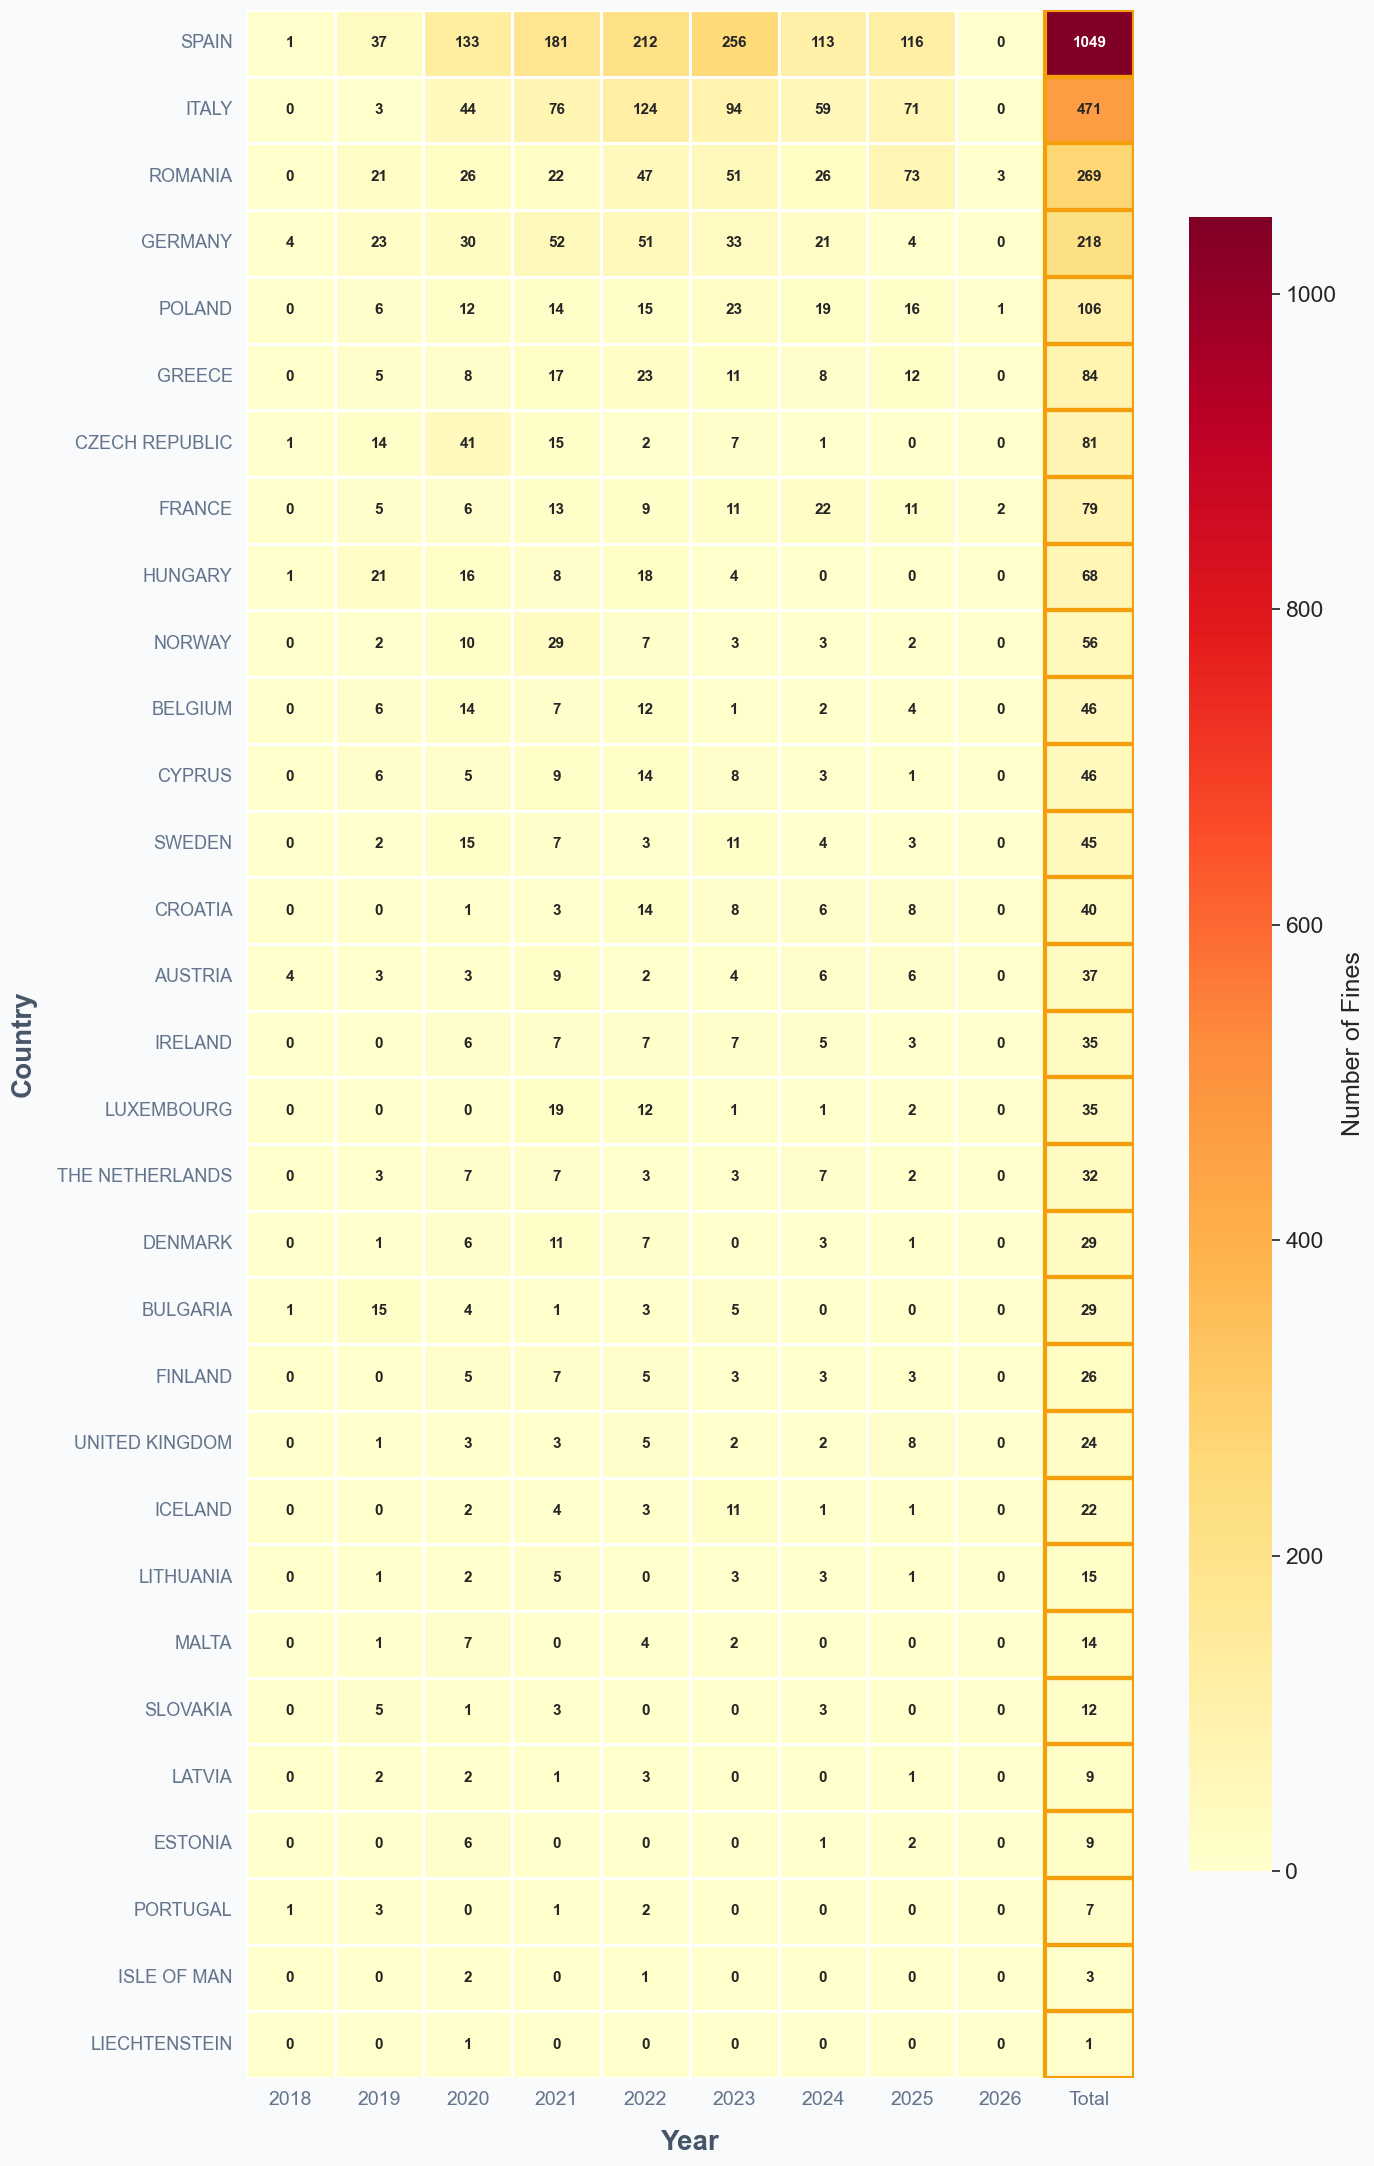

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Read CSV ---
df = pd.read_csv("gdpr_fines_summary_21_Jan_2026_v2.xlsx - figure.csv")

# --- 2. Create pivot table ---
pivot_data = df.groupby(["Country", "Year"]).size().reset_index(name="Count")
table_data = pivot_data.pivot(index="Country", columns="Year", values="Count").fillna(0)

# Add total column
table_data['Total'] = table_data.sum(axis=1)

# Sort by total
table_data = table_data.sort_values('Total', ascending=False)

# --- 3. Create heatmap ---
fig, ax = plt.subplots(figsize=(14, 22))
fig.patch.set_facecolor('#f8fafc')

# Create heatmap with annotations
sns.heatmap(
    table_data,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=2,
    linecolor='white',
    cbar_kws={'label': 'Number of Fines', 'shrink': 0.8},
    ax=ax,
    annot_kws={'fontsize': 11, 'fontweight': 'bold'},
    vmin=0,
    square=False
)

# Style
# plt.title("GDPR Fines by Country and Year - Heatmap", 
#           fontsize=26, fontweight='bold', color='#1e293b', pad=20)
plt.xlabel("Year", fontsize=20, fontweight='bold', color='#475569', labelpad=15)
plt.ylabel("Country", fontsize=20, fontweight='bold', color='#475569', labelpad=15)
plt.xticks(fontsize=14, color='#64748b', rotation=0)
plt.yticks(fontsize=13, color='#64748b', rotation=0)

# Highlight Total column
total_col_idx = len(table_data.columns) - 1
for i in range(len(table_data)):
    rect = plt.Rectangle(
        (total_col_idx, i), 1, 1,
        fill=False, edgecolor='#f59e0b',
        linewidth=3, zorder=10
    )
    ax.add_patch(rect)

plt.tight_layout()

plt.savefig("gdprfines_by_country_year_heatmap_jan_21_2026.png")
plt.savefig("gdprfines_by_country_year_heatmap_jan_21_2026.pdf")
plt.show()

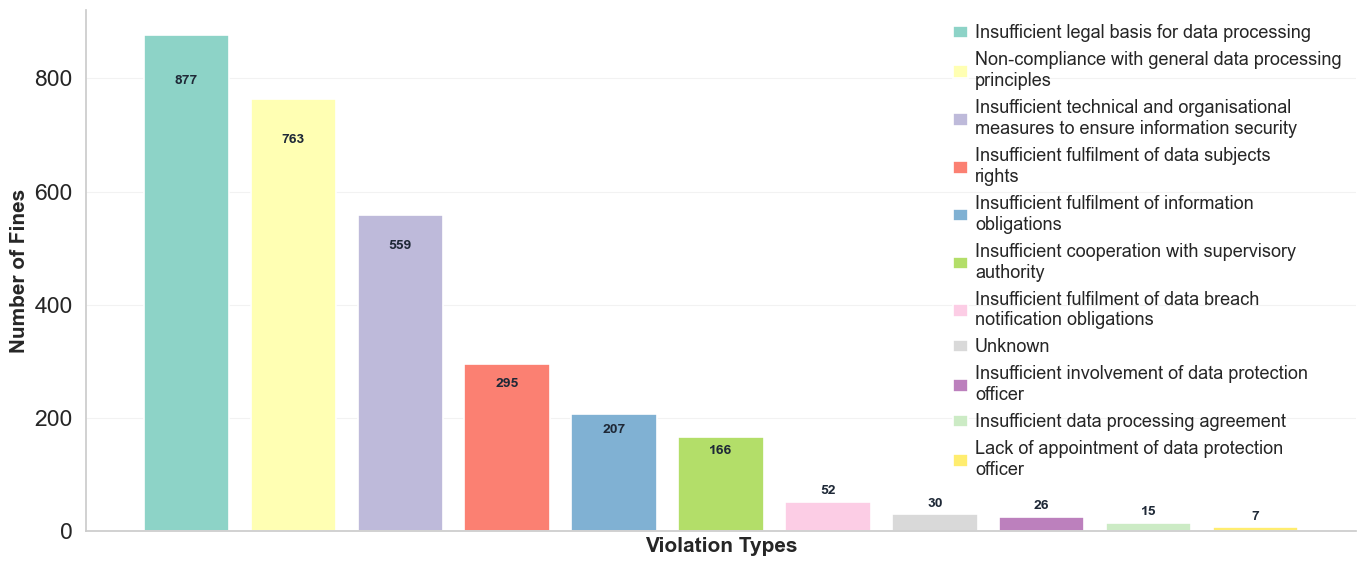

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from textwrap import fill

# -------------------------
# Data
# -------------------------
data = {
    "Reason": [
        "Insufficient legal basis for data processing",
        "Non-compliance with general data processing principles",
        "Insufficient technical and organisational measures to ensure information security",
        "Insufficient fulfilment of data subjects rights",
        "Insufficient fulfilment of information obligations",
        "Insufficient cooperation with supervisory authority",
        "Insufficient fulfilment of data breach notification obligations",
        "Unknown",
        "Insufficient involvement of data protection officer",
        "Insufficient data processing agreement",
        "Lack of appointment of data protection officer"
    ],
    "Count": [877, 763, 559, 295, 207, 166, 52, 30, 26, 15, 7]
}

df = pd.DataFrame(data).sort_values("Count", ascending=False).reset_index(drop=True)

# -------------------------
# Styling helpers
# -------------------------
def wrap_label(s, width=45):
    return fill(s, width=width)

labels_wrapped = [wrap_label(x, 45) for x in df["Reason"]]

# Choose a nice palette with distinct colors (like the screenshot)
colors = plt.cm.Set3(np.linspace(0, 1, len(df)))

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

x = np.arange(len(df))
bars = ax.bar(x, df["Count"], color=colors, edgecolor="white", linewidth=1.2)

# Values INSIDE bars (like screenshot)
for bar, val in zip(bars, df["Count"]):
    h = bar.get_height()
    # Place inside if tall enough, otherwise just above
    if h >= 60:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h - (h * 0.08),
            f"{int(val)}",
            ha="center", va="top",
            fontsize=10,
            color="#1f2937",
            fontweight="bold"
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 8,
            f"{int(val)}",
            ha="center", va="bottom",
            fontsize=10,
            color="#1f2937",
            fontweight="bold"
        )

# Axis labels like screenshot
ax.set_ylabel("Number of Fines", fontsize=15, fontweight="bold")
ax.set_xlabel("Violation Types", fontsize=15, fontweight="bold")

# Remove category labels on x-axis (screenshot uses legend instead)
ax.set_xticks([])

# Gridlines similar to screenshot
ax.grid(axis="y", alpha=0.25, linestyle="-", linewidth=0.8)
ax.set_axisbelow(True)

# Legend INSIDE top-right, wrapped text
ax.legend(
    bars,
    labels_wrapped,
    loc="upper right",
    frameon=False,
    fontsize=13,
    handlelength=0.8,
    handletextpad=0.4,
    borderaxespad=0.4
)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("gdpr_violations_type_21_Jan_2026.png")
plt.savefig("gdpr_violations_type_21_Jan_2026.pdf")
plt.show()
